# Category Intelligence — Retail Product Performance EDA

**Calibo AI Academy | Phase 1 — Mini Use Case 01 | Path 2 — KLU | Group 5**

### Management-ready analysis of six months of retail transactions

This notebook preserves the six required assignment steps and adds an **Extended Category Intelligence** layer focused on data trust, product concentration, location/category performance, revenue-vs-volume interpretation, and a manager-oriented visualization system.

> **Design principle:** the objective is not to make the notebook technically complicated. It is to make the analysis easier for a Category Manager to understand, question, and act on while staying within the required Python + Pandas + NumPy + Matplotlib + Seaborn toolset.

**Submission constraint:** everything is contained in this single `.ipynb` file. No React, Plotly, Streamlit, Dash, or separate Python application is required.

## CBIM Problem Canvas

| Canvas element | Answer |
|---|---|
| **Situation (S)** | A regional retail chain operates 12 stores across six Andhra Pradesh cities and sells five product categories. The Category Manager is preparing for a quarterly supplier review where shelf-space and promotional investment decisions will be discussed. |
| **Complication (C)** | The manager needs to distinguish genuine category momentum from short-term variation, identify products that drive or drag category performance, and understand whether discounting is associated with additional sales value. |
| **Question (Q)** | Based on January–June 2026 transaction data, which categories are growing or declining, which products drive each category, how discounts relate to transaction revenue and units, when demand is strongest, and what should be prioritised or challenged in the supplier review? |
| **SSOT** | `MUC01_Retail_Sales_Dataset.csv`, the supplied transaction-level dataset. |
| **Success definition** | A useful output gives the manager a defensible category position, specific product evidence, promotional timing guidance, transparent limitations, and clear questions for the supplier meeting. |
| **Primary stakeholder** | Category Manager — she needs to leave the review with evidence for investment, challenge, promotion timing, and the next data request. |

## Notebook Roadmap

### Required assignment analysis
1. Load and inspect the data
2. Category revenue trend over time
3. Top and bottom products by category
4. Discount effectiveness
5. Day-of-week and monthly patterns
6. Category Manager Briefing

### Extended Category Intelligence
7. Data-quality and revenue-reconciliation gate
8. Category Health Scorecard and momentum
9. Product contribution and Pareto concentration
10. Store × Category performance
11. Revenue vs. units and realized price
12. Analytical limitations and decision boundaries
13. Manager-oriented visualization dashboard with consistent visual language and optional native Matplotlib interaction

## 0. Configuration & Visual Design System

The analysis remains data-driven, but the presentation is controlled from one configuration block. This avoids hard-coded styling and makes the notebook easier for another analyst or administrator to maintain.

**Visual rules:**
- one stable color per category across the notebook;
- red/green are reserved for negative/positive business movement rather than decoration;
- business-language titles and axes;
- ₹ values use compact readable formatting;
- important findings are annotated directly where possible;
- the dashboard uses whitespace and hierarchy instead of excessive colors;
- the same metrics drive both the charts and the written briefing.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
%matplotlib widget

# Configuration: change these values to update the manager view.

DATA_FILE = "MUC01_Retail_Sales_Dataset 1.csv"
SELECTED_CATEGORY = "Electronics"
TOP_N_PRODUCTS = 5
CURRENCY = "₹"

CATEGORY_ORDER = ["Electronics", "Apparel", "Grocery", "Home & Kitchen", "Personal Care"]
DOW_ORDER = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
MONTH_ORDER = ["2026-01", "2026-02", "2026-03", "2026-04", "2026-05", "2026-06"]
DISCOUNT_ORDER = ["0%", "5%", "10%", "15%", "20%", "25%+"]

# A restrained, consistent category palette. These colors keep the same meaning everywhere.
CATEGORY_COLORS = {
    "Electronics": "#1f77b4",
    "Apparel": "#ff7f0e",
    "Grocery": "#2ca02c",
    "Home & Kitchen": "#9467bd",
    "Personal Care": "#8c564b",
}
POSITIVE_COLOR = "#2e7d32"
NEGATIVE_COLOR = "#c62828"
NEUTRAL_COLOR = "#6b7280"
DARK_TEXT = "#1f2937"
LIGHT_GRID = "#d1d5db"

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 150,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "axes.edgecolor": "#d1d5db",
    "axes.labelcolor": DARK_TEXT,
    "text.color": DARK_TEXT,
    "xtick.color": DARK_TEXT,
    "ytick.color": DARK_TEXT,
    "grid.color": LIGHT_GRID,
    "grid.alpha": 0.45,
})


def fmt_inr(x, decimals=1):
    """Compact INR formatting for charts and management summaries."""
    x = float(x)
    if abs(x) >= 1e7:
        return f"₹{x/1e7:.{decimals}f} Cr"
    if abs(x) >= 1e5:
        return f"₹{x/1e5:.{decimals}f} L"
    if abs(x) >= 1e3:
        return f"₹{x/1e3:.1f}K"
    return f"₹{x:,.0f}"


def pct(x, decimals=1):
    return f"{x:.{decimals}f}%"


def finish_axis(ax, title=None, xlabel=None, ylabel=None):
    if title:
        ax.set_title(title, pad=12, loc="left")
    if xlabel:
        ax.set_xlabel(xlabel)
    if ylabel:
        ax.set_ylabel(ylabel)
    ax.grid(axis="y", alpha=0.35)
    ax.spines[["top", "right"]].set_visible(False)
    return ax

## 0.1 Load, Clean, Validate and Create Analysis Features

The supplied dataset is treated as the single source of truth. The cleaning stage is intentionally conservative: it validates and standardizes the data rather than deleting records without a business reason.

In [2]:
if not Path(DATA_FILE).exists():
    # This fallback supports the assignment's original filename if the copied filename differs.
    alternatives = ["MUC01_Retail_Sales_Dataset.csv", "MUC01_Retail_Sales_Dataset 1.csv"]
    DATA_FILE = next((f for f in alternatives if Path(f).exists()), DATA_FILE)

if not Path(DATA_FILE).exists():
    raise FileNotFoundError(
        "Place the supplied MUC01_Retail_Sales_Dataset CSV in the same folder as this notebook."
    )

raw_df = pd.read_csv(DATA_FILE)
df = raw_df.copy()
df.columns = df.columns.str.strip()

text_cols = ["transaction_id", "store_id", "store_city", "category", "product_name"]
for col in text_cols:
    df[col] = df[col].astype("string").str.strip()

df["date"] = pd.to_datetime(df["date"], errors="coerce")
for col in ["units_sold", "unit_price", "revenue", "discount_pct"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Business-rule checks
expected_revenue = df["units_sold"] * df["unit_price"] * (1 - df["discount_pct"] / 100)
revenue_error = (df["revenue"] - expected_revenue).abs()

quality_checks = {
    "Rows loaded": len(df),
    "Columns loaded": df.shape[1],
    "Null cells": int(df.isna().sum().sum()),
    "Duplicate transaction IDs": int(df["transaction_id"].duplicated().sum()),
    "Invalid units (<=0)": int((df["units_sold"] <= 0).sum()),
    "Invalid unit prices (<0)": int((df["unit_price"] < 0).sum()),
    "Discount outside 0–30%": int(((df["discount_pct"] < 0) | (df["discount_pct"] > 30)).sum()),
    "Revenue reconciliation errors > ₹0.01": int((revenue_error > 0.01).sum()),
}

# Derived fields used consistently throughout the notebook.
df["month"] = df["date"].dt.to_period("M").astype(str)
df["day_of_week"] = df["date"].dt.day_name()
df["realized_price_per_unit"] = np.where(df["units_sold"] > 0, df["revenue"] / df["units_sold"], np.nan)

def discount_bracket(x):
    return {0: "0%", 5: "5%", 10: "10%", 15: "15%", 20: "20%"}.get(x, "25%+")

df["discount_bracket"] = df["discount_pct"].map(discount_bracket)

quality_table = pd.DataFrame({"Check": list(quality_checks.keys()), "Result": list(quality_checks.values())})
display(quality_table)

assert quality_checks["Null cells"] == 0
assert quality_checks["Duplicate transaction IDs"] == 0
assert quality_checks["Invalid units (<=0)"] == 0
assert quality_checks["Invalid unit prices (<0)"] == 0
assert quality_checks["Discount outside 0–30%"] == 0
assert quality_checks["Revenue reconciliation errors > ₹0.01"] == 0

print(f"Validated dataset: {df.shape[0]:,} transactions × {df.shape[1]} columns")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")

,Check,Result
0,Rows loaded,107836
1,Columns loaded,10
2,Null cells,0
3,Duplicate transaction IDs,0
4,Invalid units (<=0),0
5,Invalid unit prices (<0),0
6,Discount outside 0–30%,0
7,Revenue reconciliation errors > ₹0.01,0


Validated dataset: 107,836 transactions × 14 columns
Date range: 2026-01-01 to 2026-06-30


### Data-quality conclusion

The validation gate confirms that the supplied transaction table is internally consistent for the fields used in this analysis. Revenue reconciles to the documented after-discount formula within a ₹0.01 rounding tolerance. No records are removed merely to improve a chart; the notebook therefore preserves the supplied transaction population.

# 1. Load and Inspect the Data

In [3]:
print("Shape:", df.shape)
print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nNull values:")
display(df.isna().sum().to_frame("null_count"))

print("\nDescriptive summary:")
display(df.describe().T.round(2))

print("\nUnique products:", df["product_name"].nunique())
print("Unique categories:", df["category"].nunique())
print("Unique stores:", df["store_id"].nunique())
print("Unique cities:", df["store_city"].nunique())
print("Date range:", df["date"].min().date(), "to", df["date"].max().date())

Shape: (107836, 14)

Data types:


,dtype
transaction_id,string
date,datetime64[us]
store_id,string
store_city,string
category,string
product_name,string
units_sold,int64
unit_price,float64
revenue,float64
discount_pct,int64



Null values:


,null_count
transaction_id,0
date,0
store_id,0
store_city,0
category,0
product_name,0
units_sold,0
unit_price,0
revenue,0
discount_pct,0



Descriptive summary:


,count,mean,min,25%,50%,75%,max,std
date,107836,2026-04-01 18:11:48.275529,2026-01-01 00:00:00,2026-02-15 00:00:00,2026-04-02 00:00:00,2026-05-17 00:00:00,2026-06-30 00:00:00,NaN
units_sold,107836.0,2.583488,1.0,1.0,2.0,3.0,13.0,1.471616
unit_price,107836.0,1778.097787,50.02,274.8275,488.45,1039.5225,44990.14,5053.631792
revenue,107836.0,4263.920924,40.04,467.7725,1034.615,2473.335,355090.88,14243.244169
discount_pct,107836.0,7.228152,0.0,0.0,5.0,10.0,20.0,6.730445
realized_price_per_unit,107836.0,1650.542924,40.04,253.76375,451.061,961.645,44868.48,4703.656628



Unique products: 25
Unique categories: 5
Unique stores: 12
Unique cities: 6
Date range: 2026-01-01 to 2026-06-30


### Business observations

1. The dataset contains **107,836 transactions across six months**, providing a substantial base for category and product comparisons rather than a small-sample decision.
2. The chain has **five categories, 25 products, 12 stores and six cities**, which allows the analysis to move from category-level performance into product and location-level diagnosis.
3. Electronics has a disproportionate effect on total chain revenue, so its decline is strategically important even before investigating the individual products behind it.

# 2. Category Revenue Trend Over Time

This is the assignment's most important category-manager chart. The question is not only which line moved up or down, but whether the movement is large enough to change the supplier-review conversation.

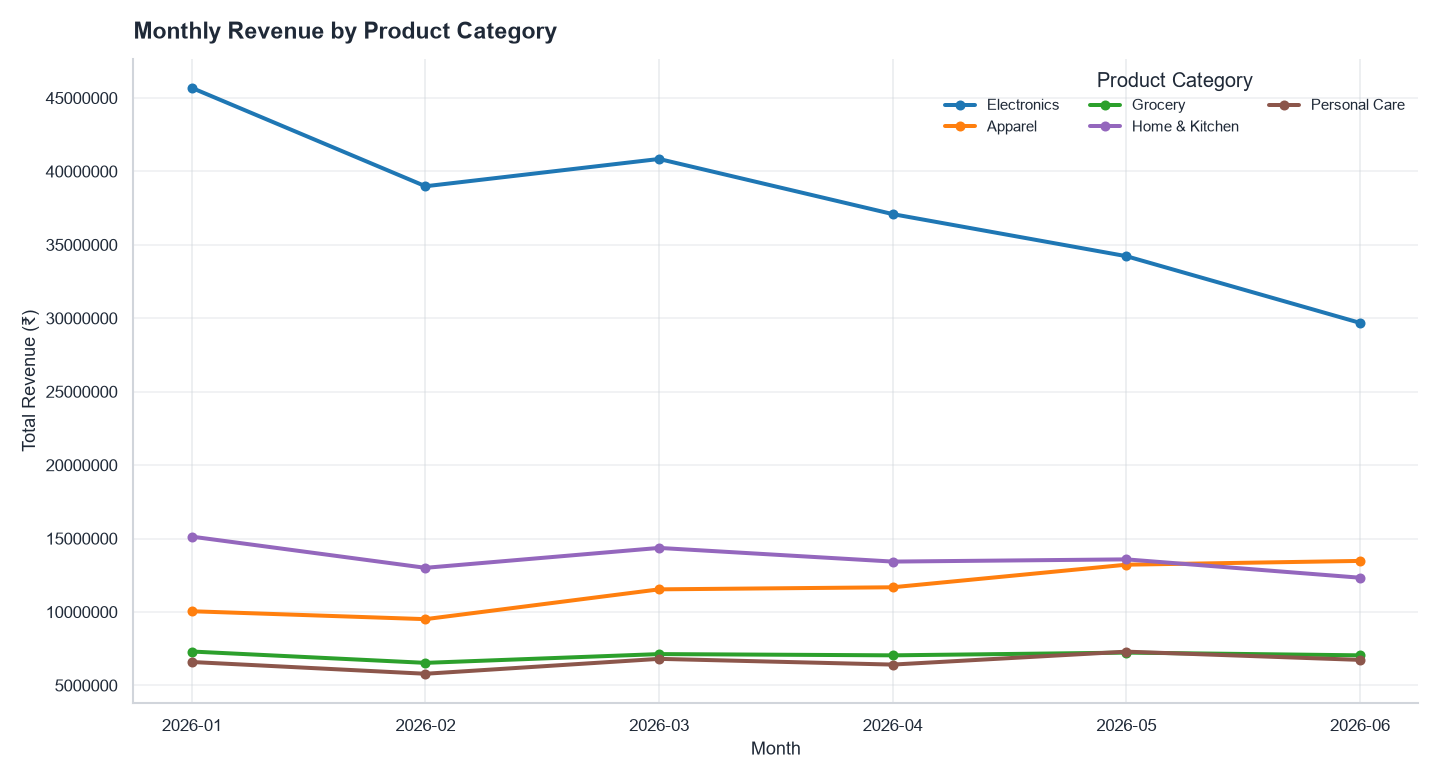

,January Revenue (₹),June Revenue (₹),Change (₹),Change (%),Monthly CV (%)
category,,,,,
Apparel,10049916.78,13476952.88,3427036.10,34.10,13.88
Personal Care,6593734.81,6737354.12,143619.31,2.18,7.52
Grocery,7307011.34,7047719.23,-259292.11,-3.55,3.87
Home & Kitchen,15130871.54,12333283.07,-2797588.47,-18.49,7.26
Electronics,45686596.63,29686824.81,-15999771.82,-35.02,14.60


Steepest decline: Electronics (-35.0%)
Strongest growth: Apparel (34.1%)
Most consistent: Grocery (monthly CV 3.87%)


In [4]:
cat_month = (
    df.groupby(["month", "category"])["revenue"].sum()
    .unstack(fill_value=0)
    .reindex(MONTH_ORDER)
)

fig, ax = plt.subplots(figsize=(12, 6.5))
for category in CATEGORY_ORDER:
    ax.plot(
        cat_month.index, cat_month[category],
        marker="o", linewidth=2.4, markersize=5,
        label=category, color=CATEGORY_COLORS[category]
    )
finish_axis(ax, "Monthly Revenue by Product Category", "Month", "Total Revenue (₹)")
ax.ticklabel_format(style="plain", axis="y")
ax.legend(title="Product Category", frameon=False, ncol=3)
plt.tight_layout()
plt.show()

cat_summary = pd.DataFrame({
    "January Revenue (₹)": cat_month.loc["2026-01"],
    "June Revenue (₹)": cat_month.loc["2026-06"],
})
cat_summary["Change (₹)"] = cat_summary["June Revenue (₹)"] - cat_summary["January Revenue (₹)"]
cat_summary["Change (%)"] = cat_summary["Change (₹)"] / cat_summary["January Revenue (₹)"] * 100

monthly_cv = (cat_month.std() / cat_month.mean() * 100).sort_values()
cat_summary["Monthly CV (%)"] = monthly_cv

display(cat_summary.sort_values("Change (%)", ascending=False).round(2))

steepest_decline = cat_summary["Change (%)"].idxmin()
strongest_growth = cat_summary["Change (%)"].idxmax()
most_consistent = monthly_cv.idxmin()
print(f"Steepest decline: {steepest_decline} ({cat_summary.loc[steepest_decline, 'Change (%)']:.1f}%)")
print(f"Strongest growth: {strongest_growth} ({cat_summary.loc[strongest_growth, 'Change (%)']:.1f}%)")
print(f"Most consistent: {most_consistent} (monthly CV {monthly_cv.loc[most_consistent]:.2f}%)")

### Business signal

**Electronics has the steepest January-to-June decline at approximately 35.0%, while Apparel grows about 34.1%. Grocery is the most consistent category by monthly coefficient of variation (3.87%).**

For the supplier review, the important distinction is that Electronics is both large and declining, so its movement has a material effect on the chain. Apparel's positive trajectory supports an investment discussion, but the decision should still be checked against margin, inventory and promotion exposure.

# 3. Top and Bottom Products by Category

The assignment requires the top two and bottom two products in every category. The extended view also measures **each product's contribution to its own category**, so the manager can see whether a product is merely first in rank or genuinely material to the category.

In [5]:
product_revenue = df.groupby(["category", "product_name"], as_index=False)["revenue"].sum()
category_totals = product_revenue.groupby("category")["revenue"].transform("sum")
product_revenue["category_contribution_pct"] = product_revenue["revenue"] / category_totals * 100

product_revenue = product_revenue.sort_values(["category", "revenue"], ascending=[True, False])

top2 = product_revenue.groupby("category", group_keys=False).head(2)
bottom2 = product_revenue.sort_values(["category", "revenue"]).groupby("category", group_keys=False).head(2)

rows = []
for category in CATEGORY_ORDER:
    tops = top2[top2["category"] == category].reset_index(drop=True)
    bottoms = bottom2[bottom2["category"] == category].reset_index(drop=True)
    rows.append({
        "Category": category,
        "Top 1 Product": tops.loc[0, "product_name"],
        "Top 1 Revenue (₹)": tops.loc[0, "revenue"],
        "Top 1 Category Share (%)": tops.loc[0, "category_contribution_pct"],
        "Top 2 Product": tops.loc[1, "product_name"],
        "Top 2 Revenue (₹)": tops.loc[1, "revenue"],
        "Bottom 2 Product": bottoms.loc[0, "product_name"],
        "Bottom 2 Revenue (₹)": bottoms.loc[0, "revenue"],
        "Bottom 1 Product": bottoms.loc[1, "product_name"],
        "Bottom 1 Revenue (₹)": bottoms.loc[1, "revenue"],
    })

product_summary = pd.DataFrame(rows)
display(product_summary.round(2))

print("\nTop 10 products by revenue:")
display(product_revenue.head(10).round(2))

,Category,Top 1 Product,Top 1 Revenue (₹),Top 1 Category Share (%),Top 2 Product,Top 2 Revenue (₹),Bottom 2 Product,Bottom 2 Revenue (₹),Bottom 1 Product,Bottom 1 Revenue (₹)
0,Electronics,Headphones,47696053.99,21.06,Laptop,46551078.39,Smart TV,41882166.21,Tablet,44744388.93
1,Apparel,Saree,14161864.63,20.38,T-Shirt,14099251.65,Kurta,13606747.03,Formal Shirt,13748976.91
2,Grocery,Rice (5kg),8562171.86,20.24,Dal (1kg),8488303.64,Sugar (1kg),8377786.05,Oil (1L),8431630.01
3,Home & Kitchen,Mixer Grinder,16903254.58,20.65,Storage Box,16676535.31,Water Bottle,15825842.17,Pressure Cooker,16142329.39
4,Personal Care,Shampoo,8168328.26,20.60,Body Lotion,8106578.00,Sunscreen,7593863.45,Toothpaste,7768812.48



Top 10 products by revenue:


,category,product_name,revenue,category_contribution_pct
3,Apparel,Saree,14161864.63,20.38
4,Apparel,T-Shirt,14099251.65,20.29
1,Apparel,Jeans,13862749.46,19.95
0,Apparel,Formal Shirt,13748976.91,19.79
2,Apparel,Kurta,13606747.03,19.58
5,Electronics,Headphones,47696053.99,21.06
6,Electronics,Laptop,46551078.39,20.55
7,Electronics,Mobile Phone,45654037.41,20.15
9,Electronics,Tablet,44744388.93,19.75
8,Electronics,Smart TV,41882166.21,18.49


### Supplier-review implication

**Electronics is the category to challenge in the review, with Smart TV the lowest-revenue product within Electronics at ₹41.88M over six months.** Apparel's strongest products provide evidence behind its positive category trajectory.

**Important attribution boundary:** the dataset contains no supplier identifier. Therefore, this notebook identifies products/categories to challenge, but does not claim that a particular named supplier is responsible for the result.

# 4. Discount Effectiveness Analysis

The assignment asks for average revenue per transaction and average units sold across discount brackets. The extended interpretation also checks the distribution of promotional exposure and realized revenue per unit.

,Transactions,Avg_Revenue_per_Transaction,Avg_Units_Sold,Avg_Realized_Price_per_Unit
discount_bracket,,,,
0%,36033.0,4685.65,2.59,1814.55
5%,23922.0,4303.73,2.59,1662.13
10%,23810.0,4005.55,2.57,1572.49
15%,11935.0,4069.16,2.60,1536.41
20%,12136.0,3631.73,2.58,1406.14
25%+,NaN,NaN,NaN,NaN


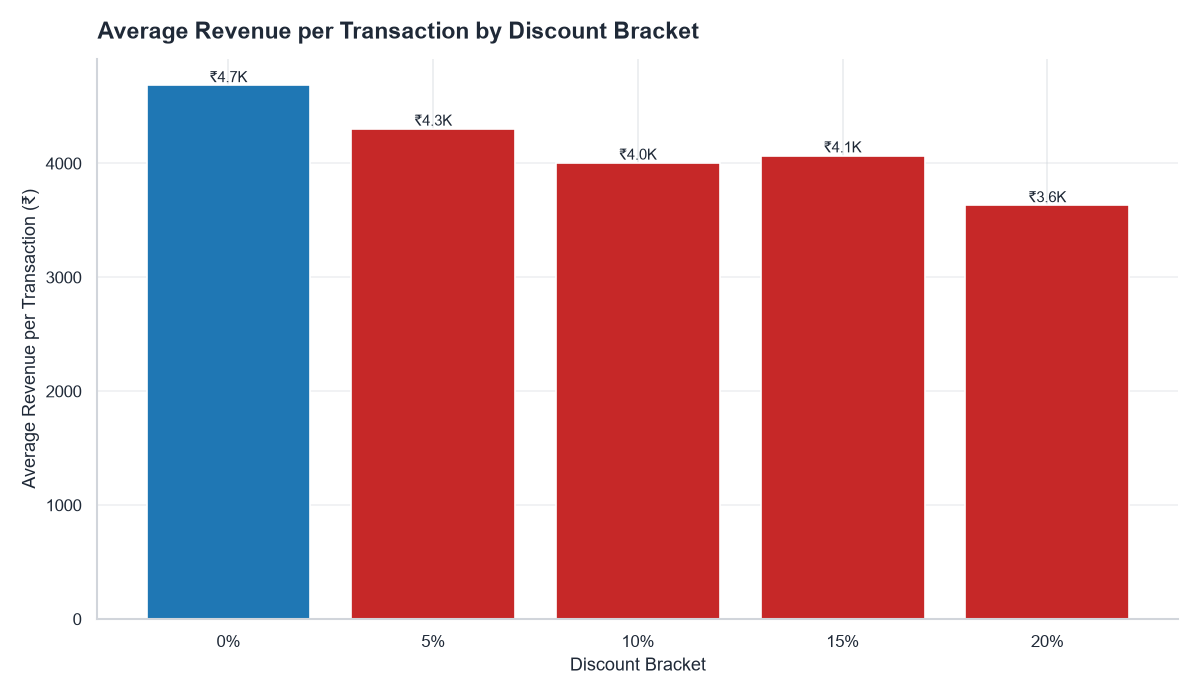

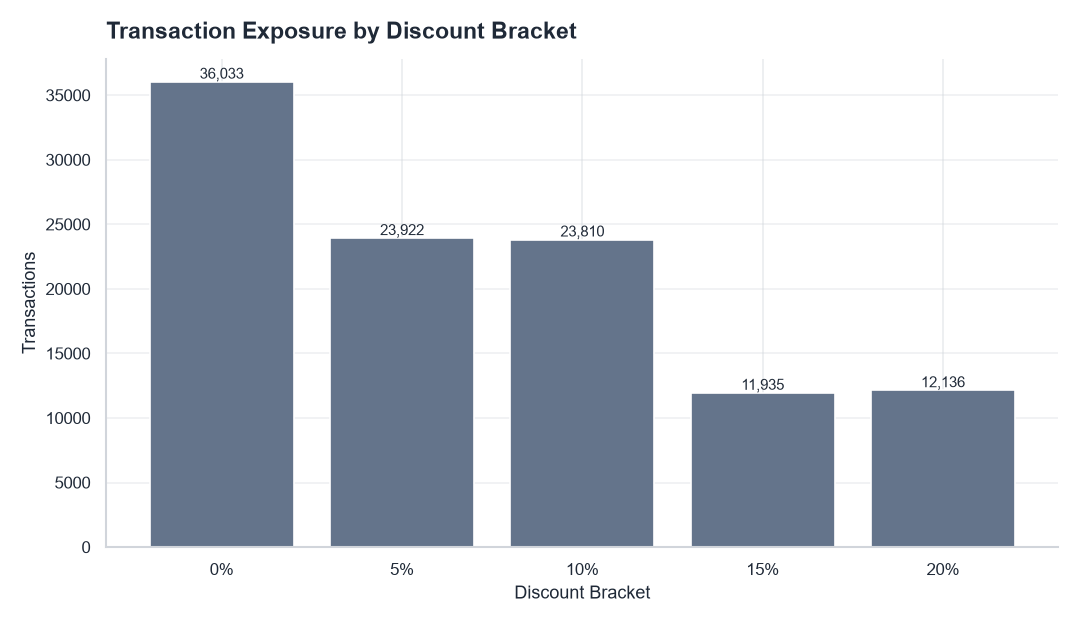

0% → 20% average revenue/transaction change: -22.5%
0% → 20% average units/transaction change: -0.2%


In [6]:
discount_summary = (
    df.groupby("discount_bracket", sort=False)
    .agg(
        Transactions=("transaction_id", "count"),
        Avg_Revenue_per_Transaction=("revenue", "mean"),
        Avg_Units_Sold=("units_sold", "mean"),
        Avg_Realized_Price_per_Unit=("realized_price_per_unit", "mean"),
    )
    .reindex(DISCOUNT_ORDER)
)

display(discount_summary.round(2))

fig, ax = plt.subplots(figsize=(10, 5.8))
observed = discount_summary.dropna(subset=["Avg_Revenue_per_Transaction"])
bar_colors = [NEGATIVE_COLOR if label not in ["0%"] else CATEGORY_COLORS["Electronics"] for label in observed.index]
ax.bar(observed.index, observed["Avg_Revenue_per_Transaction"], color=bar_colors)
for i, v in enumerate(observed["Avg_Revenue_per_Transaction"]):
    ax.text(i, v, fmt_inr(v), ha="center", va="bottom", fontsize=9)
finish_axis(ax, "Average Revenue per Transaction by Discount Bracket", "Discount Bracket", "Average Revenue per Transaction (₹)")
plt.tight_layout()
plt.show()

# Distribution of transaction exposure to each discount level.
fig, ax = plt.subplots(figsize=(9, 5.2))
observed_counts = discount_summary["Transactions"].dropna()
ax.bar(observed_counts.index, observed_counts.values, color="#64748b")
for i, v in enumerate(observed_counts):
    ax.text(i, v, f"{int(v):,}", ha="center", va="bottom", fontsize=9)
finish_axis(ax, "Transaction Exposure by Discount Bracket", "Discount Bracket", "Transactions")
plt.tight_layout()
plt.show()

base_rev = discount_summary.loc["0%", "Avg_Revenue_per_Transaction"]
twenty_rev = discount_summary.loc["20%", "Avg_Revenue_per_Transaction"]
base_units = discount_summary.loc["0%", "Avg_Units_Sold"]
twenty_units = discount_summary.loc["20%", "Avg_Units_Sold"]
rev_change = (twenty_rev / base_rev - 1) * 100
unit_change = (twenty_units / base_units - 1) * 100

print(f"0% → 20% average revenue/transaction change: {rev_change:.1f}%")
print(f"0% → 20% average units/transaction change: {unit_change:.1f}%")

### Position backed by the numbers

Higher discounts do **not** show a proportional revenue-per-transaction lift in this dataset. Average revenue per transaction falls from **₹4,685.65 at 0%** to **₹3,631.73 at 20% (−22.5%)**, while average units sold remain nearly flat (**2.59 vs 2.58**).

This supports scrutiny of deeper discounts. However, the dataset has no cost/gross-margin field, so actual margin erosion cannot be measured. The relationship is descriptive/observational rather than causal. The 25%+ bracket has no observed transactions.

# 5. Day-of-Week and Monthly Sales Patterns

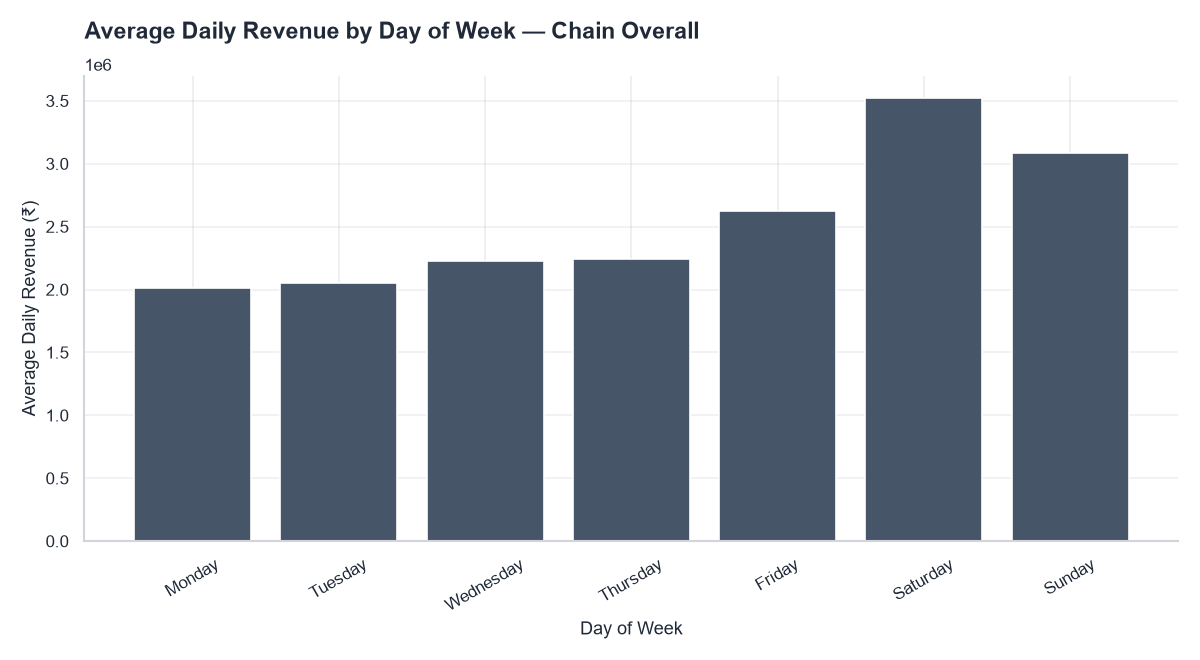

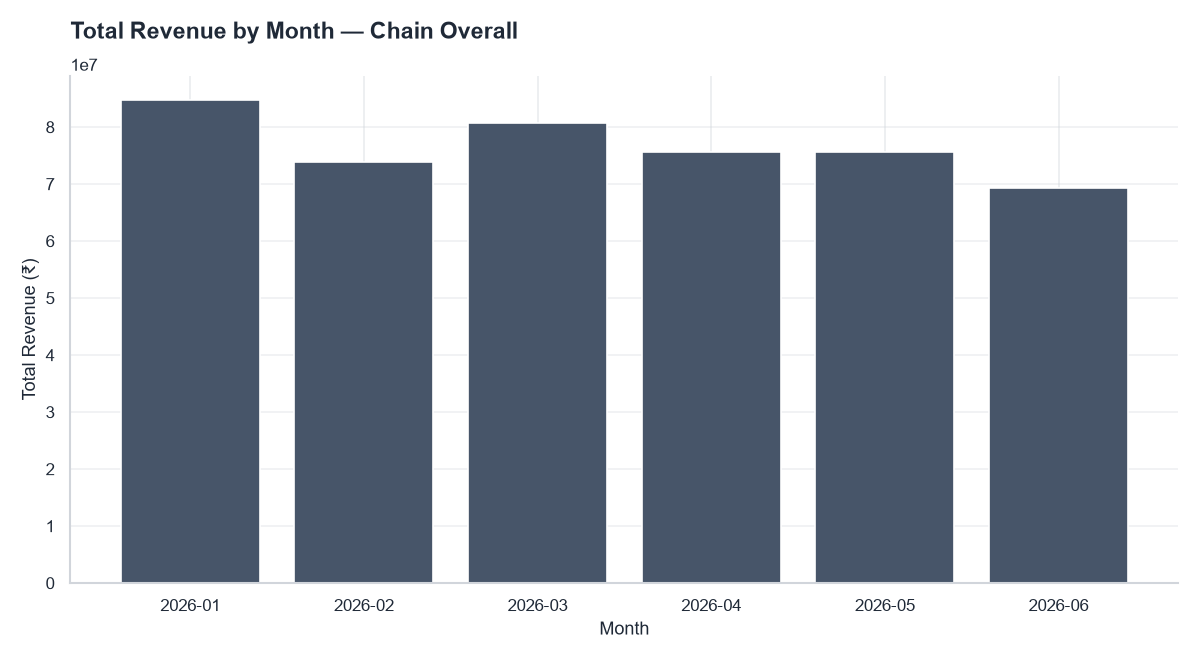

Chain best day: Saturday (₹35.2 L average daily revenue)
Chain worst day: Monday (₹20.1 L average daily revenue)
Chain best month: 2026-01 (₹8.5 Cr)
Chain worst month: 2026-06 (₹6.9 Cr)


In [7]:
daily_chain = df.groupby("date", as_index=False)["revenue"].sum().rename(columns={"revenue": "daily_revenue"})
daily_chain["day_of_week"] = daily_chain["date"].dt.day_name()
chain_dow = daily_chain.groupby("day_of_week")["daily_revenue"].mean().reindex(DOW_ORDER)
chain_month = df.groupby("month")["revenue"].sum().reindex(MONTH_ORDER)

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.bar(chain_dow.index, chain_dow.values, color="#475569")
finish_axis(ax, "Average Daily Revenue by Day of Week — Chain Overall", "Day of Week", "Average Daily Revenue (₹)")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.bar(chain_month.index, chain_month.values, color="#475569")
finish_axis(ax, "Total Revenue by Month — Chain Overall", "Month", "Total Revenue (₹)")
plt.tight_layout(); plt.show()

chain_best_day, chain_worst_day = chain_dow.idxmax(), chain_dow.idxmin()
chain_best_month, chain_worst_month = chain_month.idxmax(), chain_month.idxmin()

print(f"Chain best day: {chain_best_day} ({fmt_inr(chain_dow.max())} average daily revenue)")
print(f"Chain worst day: {chain_worst_day} ({fmt_inr(chain_dow.min())} average daily revenue)")
print(f"Chain best month: {chain_best_month} ({fmt_inr(chain_month.max())})")
print(f"Chain worst month: {chain_worst_month} ({fmt_inr(chain_month.min())})")

### Electronics: category-specific timing

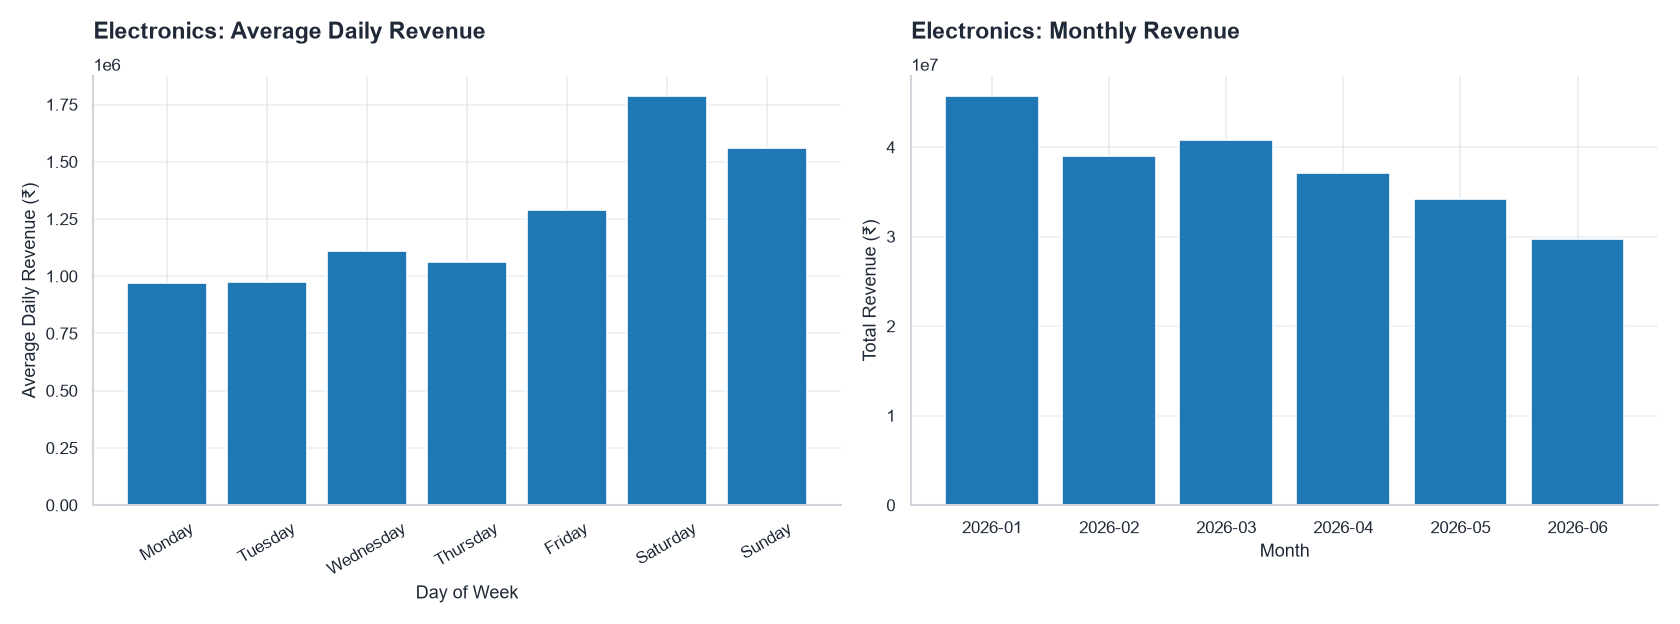

Electronics best day: Saturday (₹17.9 L average daily revenue)
Electronics worst day: Monday (₹9.7 L average daily revenue)
Electronics best month: 2026-01 (₹4.6 Cr)
Electronics worst month: 2026-06 (₹3.0 Cr)
Same weekday pattern as chain? Yes
Same monthly pattern as chain? Yes


In [8]:
interesting_category = SELECTED_CATEGORY
cat_df = df[df["category"] == interesting_category].copy()

cat_daily = cat_df.groupby("date", as_index=False)["revenue"].sum().rename(columns={"revenue": "daily_revenue"})
cat_daily["day_of_week"] = cat_daily["date"].dt.day_name()
cat_dow = cat_daily.groupby("day_of_week")["daily_revenue"].mean().reindex(DOW_ORDER)
cat_month = cat_df.groupby("month")["revenue"].sum().reindex(MONTH_ORDER)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
axes[0].bar(cat_dow.index, cat_dow.values, color=CATEGORY_COLORS[interesting_category])
finish_axis(axes[0], f"{interesting_category}: Average Daily Revenue", "Day of Week", "Average Daily Revenue (₹)")
axes[0].tick_params(axis="x", rotation=30)
axes[1].bar(cat_month.index, cat_month.values, color=CATEGORY_COLORS[interesting_category])
finish_axis(axes[1], f"{interesting_category}: Monthly Revenue", "Month", "Total Revenue (₹)")
plt.tight_layout(); plt.show()

cat_best_day, cat_worst_day = cat_dow.idxmax(), cat_dow.idxmin()
cat_best_month, cat_worst_month = cat_month.idxmax(), cat_month.idxmin()

print(f"{interesting_category} best day: {cat_best_day} ({fmt_inr(cat_dow.max())} average daily revenue)")
print(f"{interesting_category} worst day: {cat_worst_day} ({fmt_inr(cat_dow.min())} average daily revenue)")
print(f"{interesting_category} best month: {cat_best_month} ({fmt_inr(cat_month.max())})")
print(f"{interesting_category} worst month: {cat_worst_month} ({fmt_inr(cat_month.min())})")

same_day_pattern = chain_best_day == cat_best_day and chain_worst_day == cat_worst_day
same_month_pattern = chain_best_month == cat_best_month and chain_worst_month == cat_worst_month
print(f"Same weekday pattern as chain? {'Yes' if same_day_pattern else 'No'}")
print(f"Same monthly pattern as chain? {'Yes' if same_month_pattern else 'No'}")

### Promotional timing interpretation

The chain's strongest day is **Saturday** and its weakest is **Monday**. The selected category is explicitly compared against the chain rather than assumed to behave identically. This supports a targeted promotional calendar: use strong-demand periods to capture demand efficiently and use weaker periods for controlled experiments rather than automatically applying broad discounts.

# 7. Extended Category Intelligence — Category Health Scorecard

This section turns several separate calculations into one management view. It is intentionally descriptive rather than an arbitrary numerical score.

In [9]:
category_health = cat_summary.copy()
category_health["Revenue Share (%)"] = category_health["June Revenue (₹)"] / category_health["June Revenue (₹)"].sum() * 100
category_health["Signal"] = np.select(
    [category_health["Change (%)"] >= 10, category_health["Change (%)"] <= -10],
    ["Growing", "Declining"],
    default="Stable / mixed"
)
category_health = category_health[["January Revenue (₹)", "June Revenue (₹)", "Change (%)", "Monthly CV (%)", "Revenue Share (%)", "Signal"]]
display(category_health.sort_values("Change (%)", ascending=False).round(2))

,January Revenue (₹),June Revenue (₹),Change (%),Monthly CV (%),Revenue Share (%),Signal
category,,,,,,
Apparel,10049916.78,13476952.88,34.10,13.88,19.45,Growing
Personal Care,6593734.81,6737354.12,2.18,7.52,9.72,Stable / mixed
Grocery,7307011.34,7047719.23,-3.55,3.87,10.17,Stable / mixed
Home & Kitchen,15130871.54,12333283.07,-18.49,7.26,17.80,Declining
Electronics,45686596.63,29686824.81,-35.02,14.60,42.85,Declining


# 8. Extended Category Intelligence — Product Revenue Concentration

The required top/bottom analysis tells us which products rank highest and lowest. A Pareto-style view answers a different question: **how concentrated is revenue among a small number of products?**

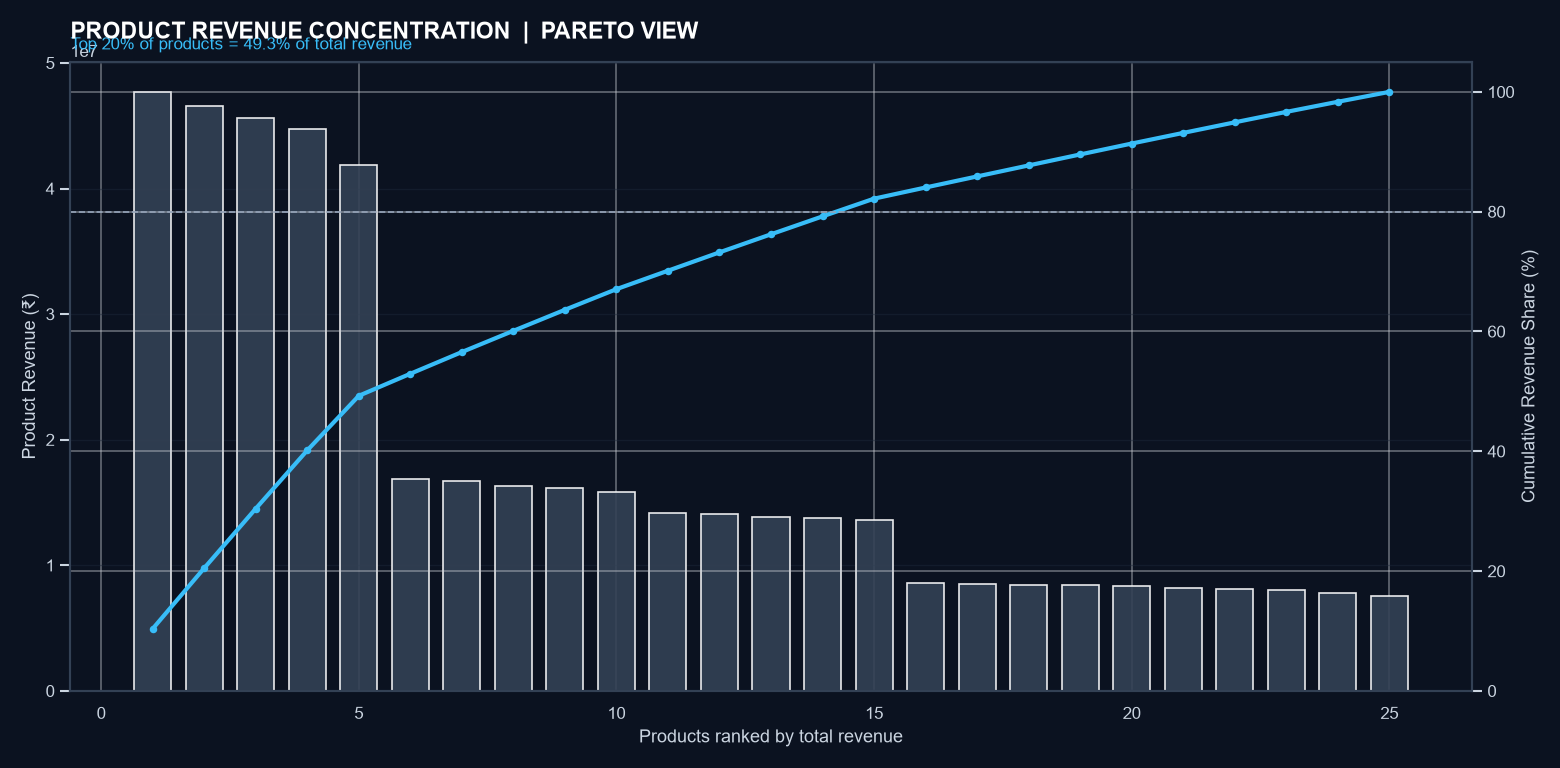

Top 20% of products account for approximately 49.3% of total revenue.


,category,product_name,revenue,Revenue Share (%),Cumulative Revenue Share (%)
0,Electronics,Headphones,47696053.99,10.37,10.37
1,Electronics,Laptop,46551078.39,10.12,20.50
2,Electronics,Mobile Phone,45654037.41,9.93,30.43
3,Electronics,Tablet,44744388.93,9.73,40.16
4,Electronics,Smart TV,41882166.21,9.11,49.27
5,Home & Kitchen,Mixer Grinder,16903254.58,3.68,52.94
6,Home & Kitchen,Storage Box,16676535.31,3.63,56.57
7,Home & Kitchen,Dinner Set,16297759.88,3.54,60.11
8,Home & Kitchen,Pressure Cooker,16142329.39,3.51,63.62
9,Home & Kitchen,Water Bottle,15825842.17,3.44,67.07


In [10]:
# Rebuild this table locally so the Extended Intelligence section is self-contained.
# This prevents a NameError if Step 3's cell was not executed before this cell.
product_revenue = (
    df.groupby(["category", "product_name"], as_index=False)
      .agg(revenue=("revenue", "sum"), units_sold=("units_sold", "sum"), transactions=("transaction_id", "count"))
)
product_revenue["category_revenue"] = product_revenue.groupby("category")["revenue"].transform("sum")
product_revenue["category_contribution_pct"] = product_revenue["revenue"] / product_revenue["category_revenue"] * 100
product_revenue = product_revenue.drop(columns=["category_revenue"])

pareto = product_revenue.sort_values("revenue", ascending=False).reset_index(drop=True).copy()
pareto["Revenue Share (%)"] = pareto["revenue"] / pareto["revenue"].sum() * 100
pareto["Cumulative Revenue Share (%)"] = pareto["Revenue Share (%)"].cumsum()

n_top20 = max(1, int(np.ceil(len(pareto) * 0.20)))
top20_share = pareto.loc[:n_top20-1, "Revenue Share (%)"].sum()

fig, ax1 = plt.subplots(figsize=(13, 6.4))
fig.patch.set_facecolor("#0b1220")
ax1.set_facecolor("#0b1220")
x = np.arange(1, len(pareto) + 1)
ax1.bar(x, pareto["revenue"], color="#334155", alpha=0.9, width=0.72)
ax1.set_xlabel("Products ranked by total revenue", color="#cbd5e1")
ax1.set_ylabel("Product Revenue (₹)", color="#cbd5e1")
ax1.tick_params(colors="#cbd5e1")
for spine in ax1.spines.values(): spine.set_color("#334155")
ax2 = ax1.twinx()
ax2.plot(x, pareto["Cumulative Revenue Share (%)"], color="#38bdf8", marker="o", markersize=3.5, linewidth=2.5)
ax2.axhline(80, linestyle="--", color="#94a3b8", linewidth=1)
ax2.set_ylabel("Cumulative Revenue Share (%)", color="#cbd5e1")
ax2.set_ylim(0, 105)
ax2.tick_params(colors="#cbd5e1")
for spine in ax2.spines.values(): spine.set_color("#334155")
ax1.set_title("PRODUCT REVENUE CONCENTRATION  |  PARETO VIEW", loc="left", pad=14, color="white", fontweight="bold", fontsize=14)
ax1.text(0, 1.02, f"Top 20% of products = {top20_share:.1f}% of total revenue", transform=ax1.transAxes, color="#38bdf8", fontsize=10)
ax1.grid(axis="y", color="#1e293b", linewidth=0.8)
ax1.set_axisbelow(True)
plt.tight_layout(); plt.show()

print(f"Top 20% of products account for approximately {top20_share:.1f}% of total revenue.")
display(pareto.head(10)[["category", "product_name", "revenue", "Revenue Share (%)", "Cumulative Revenue Share (%)"]].round(2))


### Business interpretation

Revenue is not evenly distributed across the assortment. Approximately **49.3% of total revenue comes from the top 20% of products** in this dataset. This suggests supplier conversations should distinguish core revenue-driving products from the long tail instead of treating every SKU as equally important.

# 9. Extended Category Intelligence — Store × Category Performance

A category trend can hide geographic concentration. The heatmap below asks whether category performance is broad-based across the six cities or concentrated in particular locations.

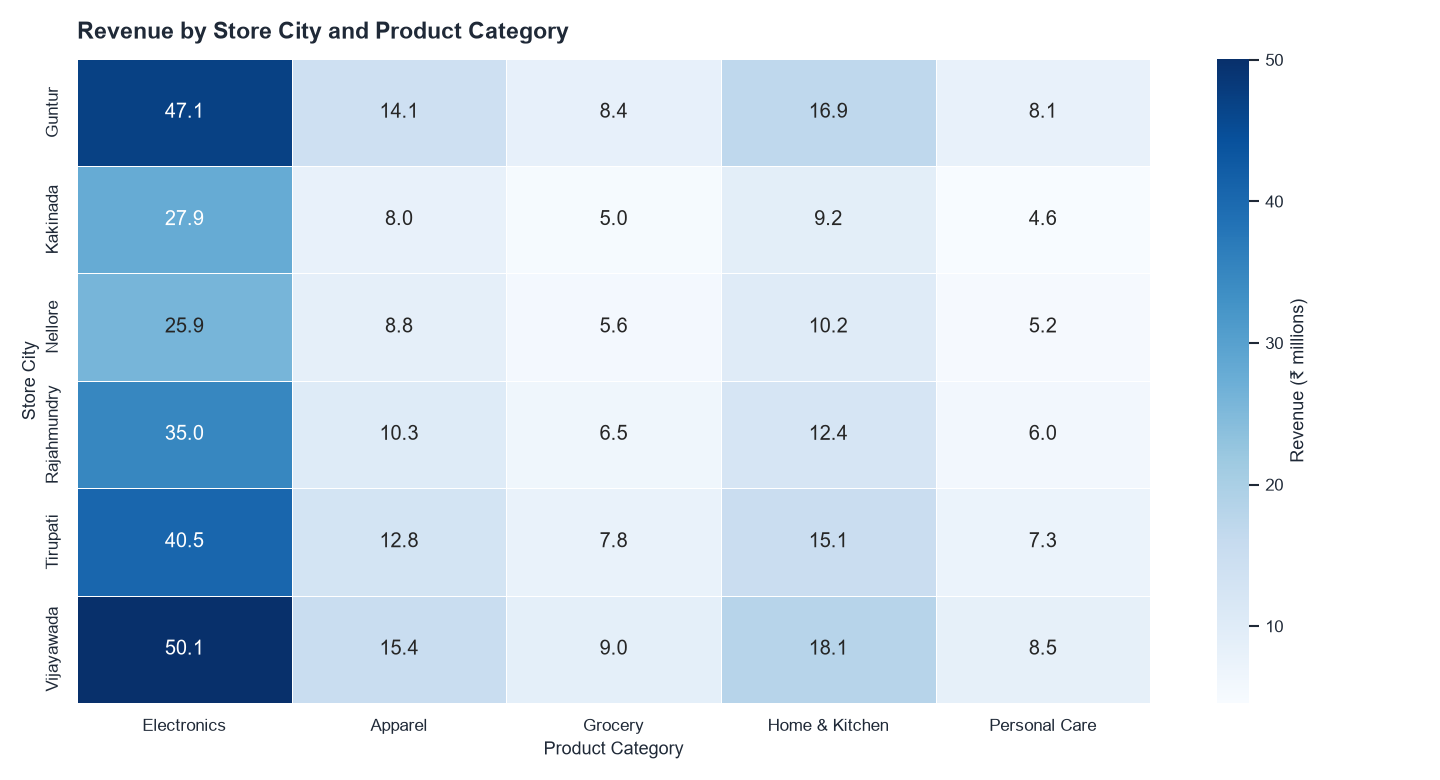

Share of each category's revenue by city (%):


category,Electronics,Apparel,Grocery,Home & Kitchen,Personal Care
store_city,,,,,
Guntur,20.8,20.3,19.9,20.6,20.4
Kakinada,12.3,11.5,11.9,11.3,11.5
Nellore,11.5,12.7,13.2,12.4,13.1
Rajahmundry,15.4,14.9,15.4,15.1,15.0
Tirupati,17.9,18.5,18.4,18.4,18.5
Vijayawada,22.1,22.2,21.2,22.2,21.5


In [11]:
store_category = pd.pivot_table(
    df, index="store_city", columns="category", values="revenue", aggfunc="sum", fill_value=0
).reindex(columns=CATEGORY_ORDER)

fig, ax = plt.subplots(figsize=(12, 6.5))
sns.heatmap(store_category / 1e6, annot=True, fmt=".1f", cmap="Blues", linewidths=0.5, cbar_kws={"label": "Revenue (₹ millions)"}, ax=ax)
ax.set_title("Revenue by Store City and Product Category", loc="left", pad=12, fontweight="bold")
ax.set_xlabel("Product Category")
ax.set_ylabel("Store City")
plt.tight_layout(); plt.show()

store_category_share = store_category.div(store_category.sum(axis=0), axis=1) * 100
print("Share of each category's revenue by city (%):")
display(store_category_share.round(1))

### Business interpretation

The location view is diagnostic rather than a standalone recommendation. If a category's decline is concentrated in a small number of cities, the manager should investigate local assortment, availability or promotional exposure before treating the issue as a chain-wide supplier problem.

# 10. Extended Category Intelligence — Revenue vs Units and Realized Price

Revenue can change because of volume, realized selling price, product mix, or discounts. Looking at revenue alone can therefore overstate or understate demand changes.

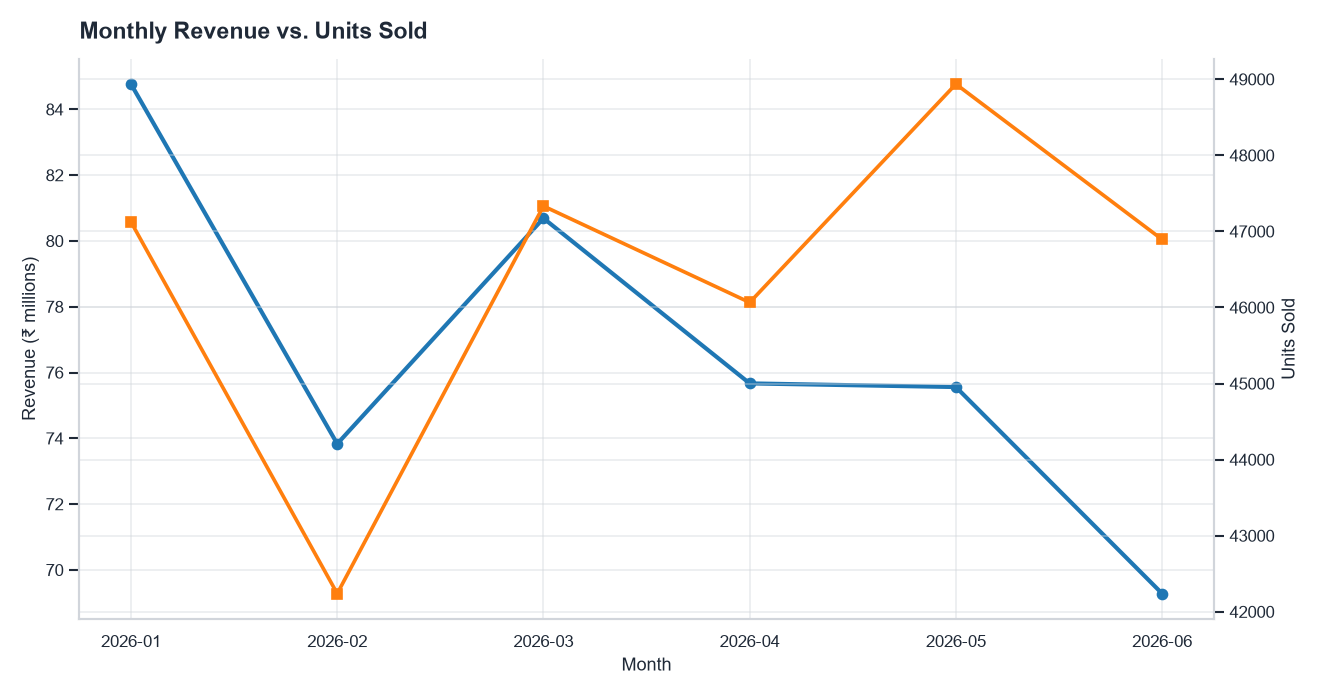

,Revenue,Units,Transactions,Realized Revenue per Unit
month,,,,
2026-01,84768131.10,47124,18251,1798.83
2026-02,73833666.23,42239,16475,1748.00
2026-03,80689884.84,47333,18159,1704.73
2026-04,75670487.12,46066,17805,1642.65
2026-05,75559873.38,48937,18904,1544.02
2026-06,69282134.11,46894,18242,1477.42


In [12]:
monthly_drivers = df.groupby("month").agg(
    Revenue=("revenue", "sum"),
    Units=("units_sold", "sum"),
    Transactions=("transaction_id", "count"),
).reindex(MONTH_ORDER)
monthly_drivers["Realized Revenue per Unit"] = monthly_drivers["Revenue"] / monthly_drivers["Units"]

fig, ax1 = plt.subplots(figsize=(11, 5.8))
ax1.plot(monthly_drivers.index, monthly_drivers["Revenue"] / 1e6, marker="o", linewidth=2.5, label="Revenue (₹M)", color="#1f77b4")
ax1.set_xlabel("Month")
ax1.set_ylabel("Revenue (₹ millions)")
ax1.spines["top"].set_visible(False)
ax2 = ax1.twinx()
ax2.plot(monthly_drivers.index, monthly_drivers["Units"], marker="s", linewidth=2.2, label="Units Sold", color="#ff7f0e")
ax2.set_ylabel("Units Sold")
ax2.spines["top"].set_visible(False)
ax1.set_title("Monthly Revenue vs. Units Sold", loc="left", pad=12, fontweight="bold")
plt.tight_layout(); plt.show()

display(monthly_drivers.round(2))

### Interpretation

The purpose of this view is to separate **value movement from volume movement**. A falling revenue line accompanied by stable units suggests a different management question from falling revenue accompanied by falling units. The realized-revenue-per-unit column adds a third lens for price/discount mix, without claiming causal price effects.

# 11. Extended Category Intelligence — Product Performance Map

This map combines **units sold** and **revenue** so the manager can distinguish high-volume products from high-value products. It is descriptive and does not impose an arbitrary score.

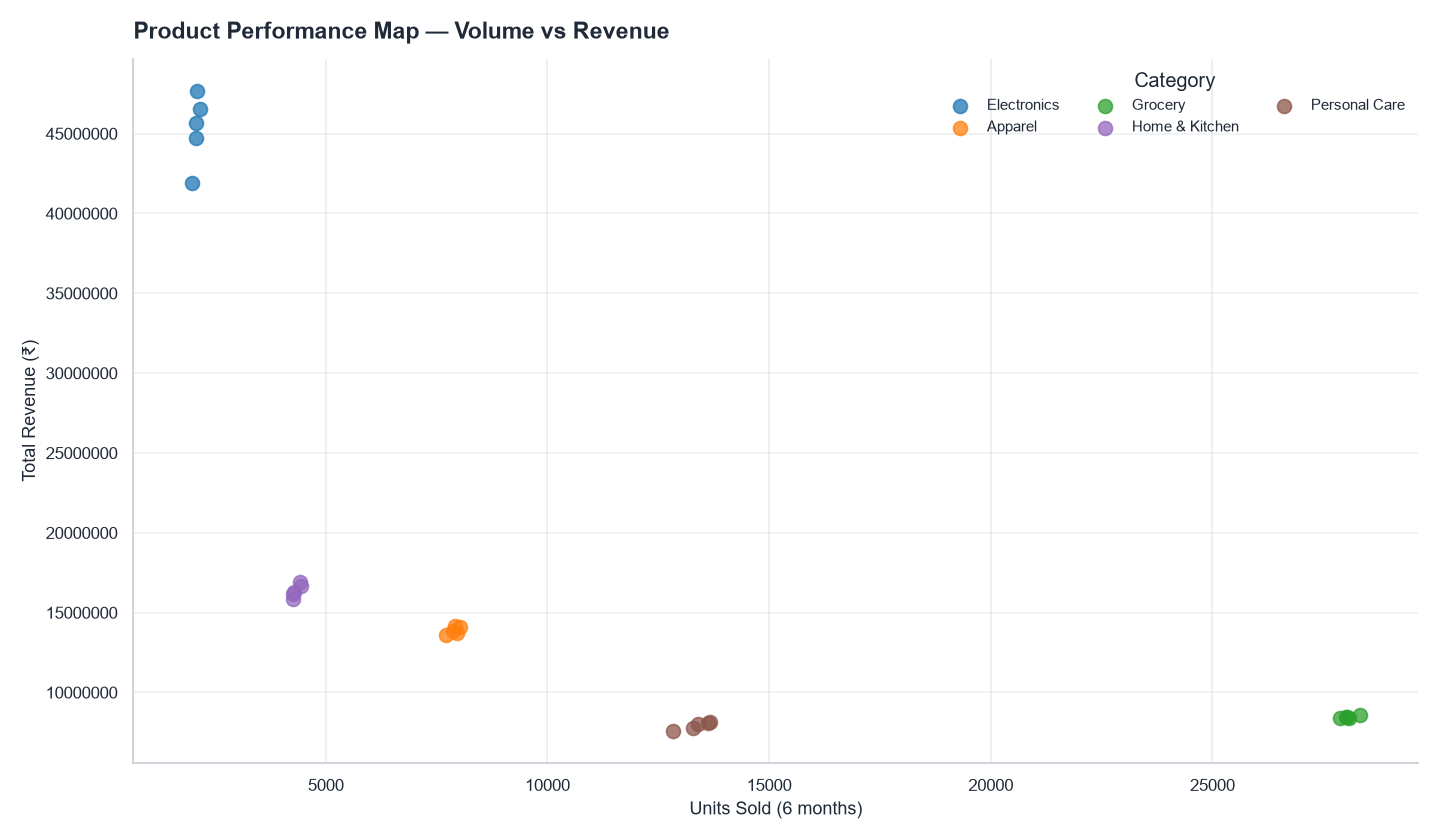

In [15]:
product_perf = df.groupby(["category", "product_name"]).agg(
    Revenue=("revenue", "sum"),
    Units=("units_sold", "sum"),
).reset_index()
product_perf["Revenue_per_Unit"] = product_perf["Revenue"] / product_perf["Units"]

fig, ax = plt.subplots(figsize=(12, 7))
for category in CATEGORY_ORDER:
    sub = product_perf[product_perf["category"] == category]
    ax.scatter(sub["Units"], sub["Revenue"], s=70, alpha=0.75, label=category, color=CATEGORY_COLORS[category])

finish_axis(ax, "Product Performance Map — Volume vs Revenue", "Units Sold (6 months)", "Total Revenue (₹)")
ax.ticklabel_format(style="plain", axis="both")
ax.legend(title="Category", frameon=False, ncol=3)
plt.tight_layout(); plt.show()

# 12. Extended UI / UX Layer — Executive Category Intelligence Cockpit

The notebook stays within the allowed stack: Pandas, NumPy, Matplotlib and Seaborn.
The visual language is intentionally closer to an executive BI cockpit than a classroom chart:
- dark canvas + restrained neutral panels
- category-specific accent color
- KPI cards with strong hierarchy
- direct labels and decision annotations
- a metric/category control panel
- a hover inspector that reveals the full monthly record

**Important:** native Matplotlib mouse events are live when the active Jupyter backend supports them. In a static inline renderer, the same dashboard remains available as a non-interactive executed chart.


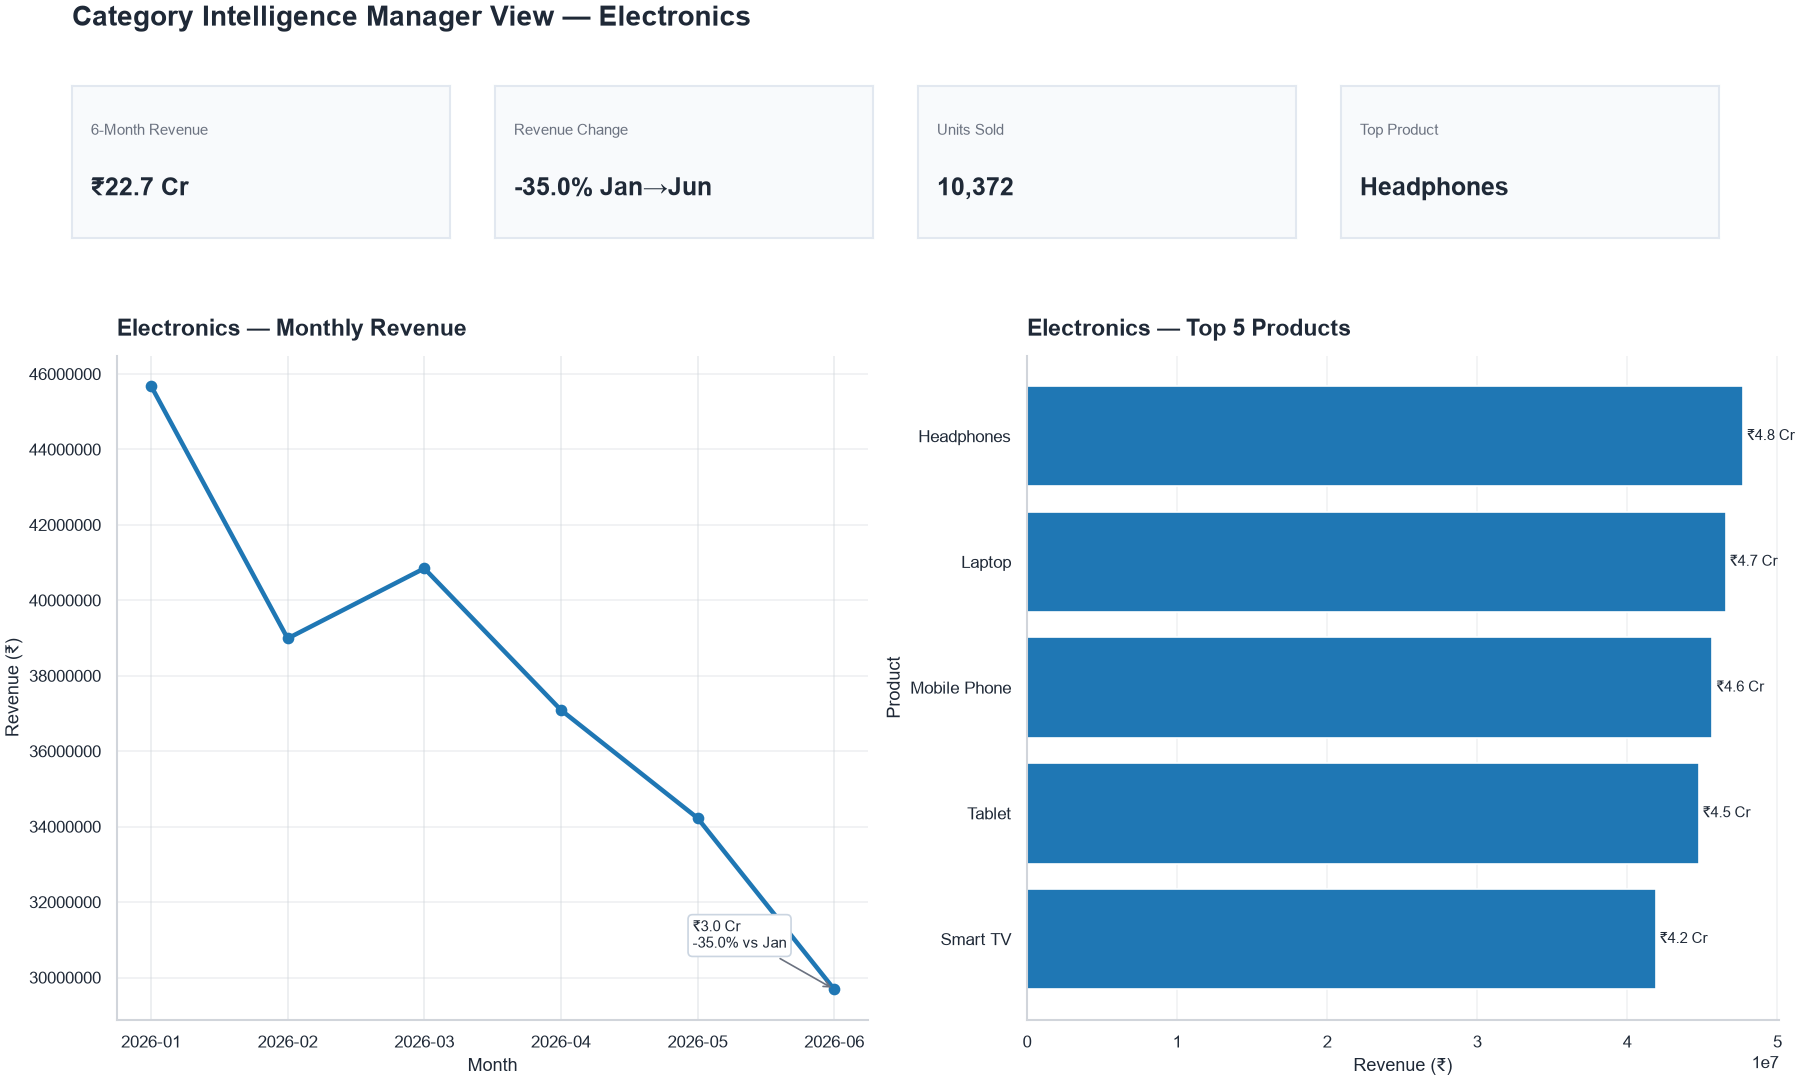

In [18]:
def manager_category_view(category=SELECTED_CATEGORY, top_n=TOP_N_PRODUCTS):
    """Create a compact manager view for one category using only the prepared data."""
    if category not in CATEGORY_ORDER:
        raise ValueError(f"Unknown category: {category}")

    sub = df[df["category"] == category]
    month_rev = sub.groupby("month")["revenue"].sum().reindex(MONTH_ORDER)
    products = sub.groupby("product_name")["revenue"].sum().sort_values(ascending=False).head(top_n)
    days = sub.groupby("day_of_week")["revenue"].sum()
    day_order_present = [d for d in DOW_ORDER if d in days.index]
    days = days.reindex(day_order_present)

    jan = month_rev.iloc[0]
    jun = month_rev.iloc[-1]
    change = (jun / jan - 1) * 100

    fig = plt.figure(figsize=(15, 9), constrained_layout=True)
    gs = fig.add_gridspec(2, 2, height_ratios=[1.0, 2.4])

    # KPI cards
    total_rev = sub["revenue"].sum()
    total_units = sub["units_sold"].sum()
    top_product = products.index[0]
    kpis = [
        ("6-Month Revenue", fmt_inr(total_rev)),
        ("Revenue Change", f"{change:+.1f}% Jan→Jun"),
        ("Units Sold", f"{int(total_units):,}"),
        ("Top Product", top_product),
    ]
    for i, (label, value) in enumerate(kpis):
        ax = fig.add_subplot(gs[0, i//2]) if False else None

    # A dedicated KPI area across the top.
    kpi_axes = [fig.add_axes([0.04 + i*0.235, 0.78, 0.21, 0.14]) for i in range(4)]
    for ax, (label, value) in zip(kpi_axes, kpis):
        ax.set_facecolor("#f8fafc")
        for spine in ax.spines.values():
            spine.set_color("#e2e8f0")
        ax.set_xticks([]); ax.set_yticks([])
        ax.text(0.05, 0.68, label, transform=ax.transAxes, fontsize=9, color=NEUTRAL_COLOR)
        ax.text(0.05, 0.28, value, transform=ax.transAxes, fontsize=15, fontweight="bold", color=DARK_TEXT)

    ax1 = fig.add_subplot(gs[1, 0])
    ax1.plot(month_rev.index, month_rev.values, marker="o", linewidth=2.7, color=CATEGORY_COLORS[category])
    finish_axis(ax1, f"{category} — Monthly Revenue", "Month", "Revenue (₹)")
    ax1.ticklabel_format(style="plain", axis="y")
    ax1.annotate(
        f"{fmt_inr(month_rev.iloc[-1])}\n{change:+.1f}% vs Jan",
        xy=(month_rev.index[-1], month_rev.iloc[-1]),
        xytext=(-85, 25), textcoords="offset points",
        arrowprops=dict(arrowstyle="->", color=NEUTRAL_COLOR), fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#cbd5e1")
    )

    ax2 = fig.add_subplot(gs[1, 1])
    bars = ax2.barh(products.index[::-1], products.values[::-1], color=CATEGORY_COLORS[category])
    finish_axis(ax2, f"{category} — Top {top_n} Products", "Revenue (₹)", "Product")
    ax2.grid(axis="x", alpha=0.3); ax2.grid(axis="y", visible=False)
    for bar, value in zip(bars, products.values[::-1]):
        ax2.text(value, bar.get_y() + bar.get_height()/2, f" {fmt_inr(value)}", va="center", fontsize=9)

    fig.suptitle(f"Category Intelligence Manager View — {category}", fontsize=17, fontweight="bold", x=0.04, ha="left")
    plt.show()

manager_category_view()

### Optional native hover helper

Run the helper below after a plot if the current Jupyter environment exposes a live Matplotlib canvas. It does not require a new plotting library. In a static inline backend, the helper simply has no visible mouse interaction; the underlying chart remains usable and the dashboard configuration remains available.

In [16]:
def add_full_month_hover(fig, ax, monthly):
    """Attach a rich native Matplotlib hover inspector to a monthly dashboard line."""
    annotation = ax.annotate(
        "", xy=(0, 0), xytext=(14, 16), textcoords="offset points",
        bbox=dict(boxstyle="round,pad=0.55", fc="#111827", ec="#38bdf8", alpha=0.98),
        arrowprops=dict(arrowstyle="->", color="#38bdf8", lw=1.2),
        color="#f8fafc", fontsize=8.5, linespacing=1.45
    )
    annotation.set_visible(False)
    xs = np.arange(len(monthly)); ys = monthly["Revenue"].to_numpy()
    def on_move(event):
        if event.inaxes != ax or event.xdata is None or event.ydata is None:
            if annotation.get_visible(): annotation.set_visible(False); fig.canvas.draw_idle()
            return
        distances = (event.xdata-xs)**2 + ((event.ydata-ys)/max(np.ptp(ys),1))**2
        idx=int(np.argmin(distances))
        close=abs(event.xdata-xs[idx])<=0.24 and abs(event.ydata-ys[idx])<=max(np.ptp(ys)*0.08,1)
        if close:
            row=monthly.iloc[idx]; month=monthly.index[idx]; mom=row["MoM %"]
            annotation.xy=(xs[idx],ys[idx])
            annotation.set_text(
                f"{month}\nRevenue        {fmt_inr(row['Revenue'])}\n"
                f"Units sold      {int(row['Units']):,}\n"
                f"Transactions    {int(row['Transactions']):,}\n"
                f"Realized/unit   ₹{row['Realized Price / Unit']:,.2f}\n"
                f"MoM revenue     {'—' if pd.isna(mom) else f'{mom:+.1f}%'}"
            )
            annotation.set_visible(True)
        elif annotation.get_visible(): annotation.set_visible(False)
        fig.canvas.draw_idle()
    connection=fig.canvas.mpl_connect("motion_notify_event",on_move)
    return annotation,connection

_hover_annotation,_hover_connection=add_full_month_hover(fig_manager,ax_manager,manager_monthly)
print("Hover inspector attached to the manager dashboard. Live response depends on the active Matplotlib/Jupyter backend.")


Hover inspector attached to the manager dashboard. Live response depends on the active Matplotlib/Jupyter backend.


## 12.1 Interactive Control Desk — Category × Metric

Use the native Matplotlib control desk to switch the category and metric without creating another notebook or adding a dashboard framework. The control panel is intentionally compact: it behaves like a report filter rather than a decorative widget.


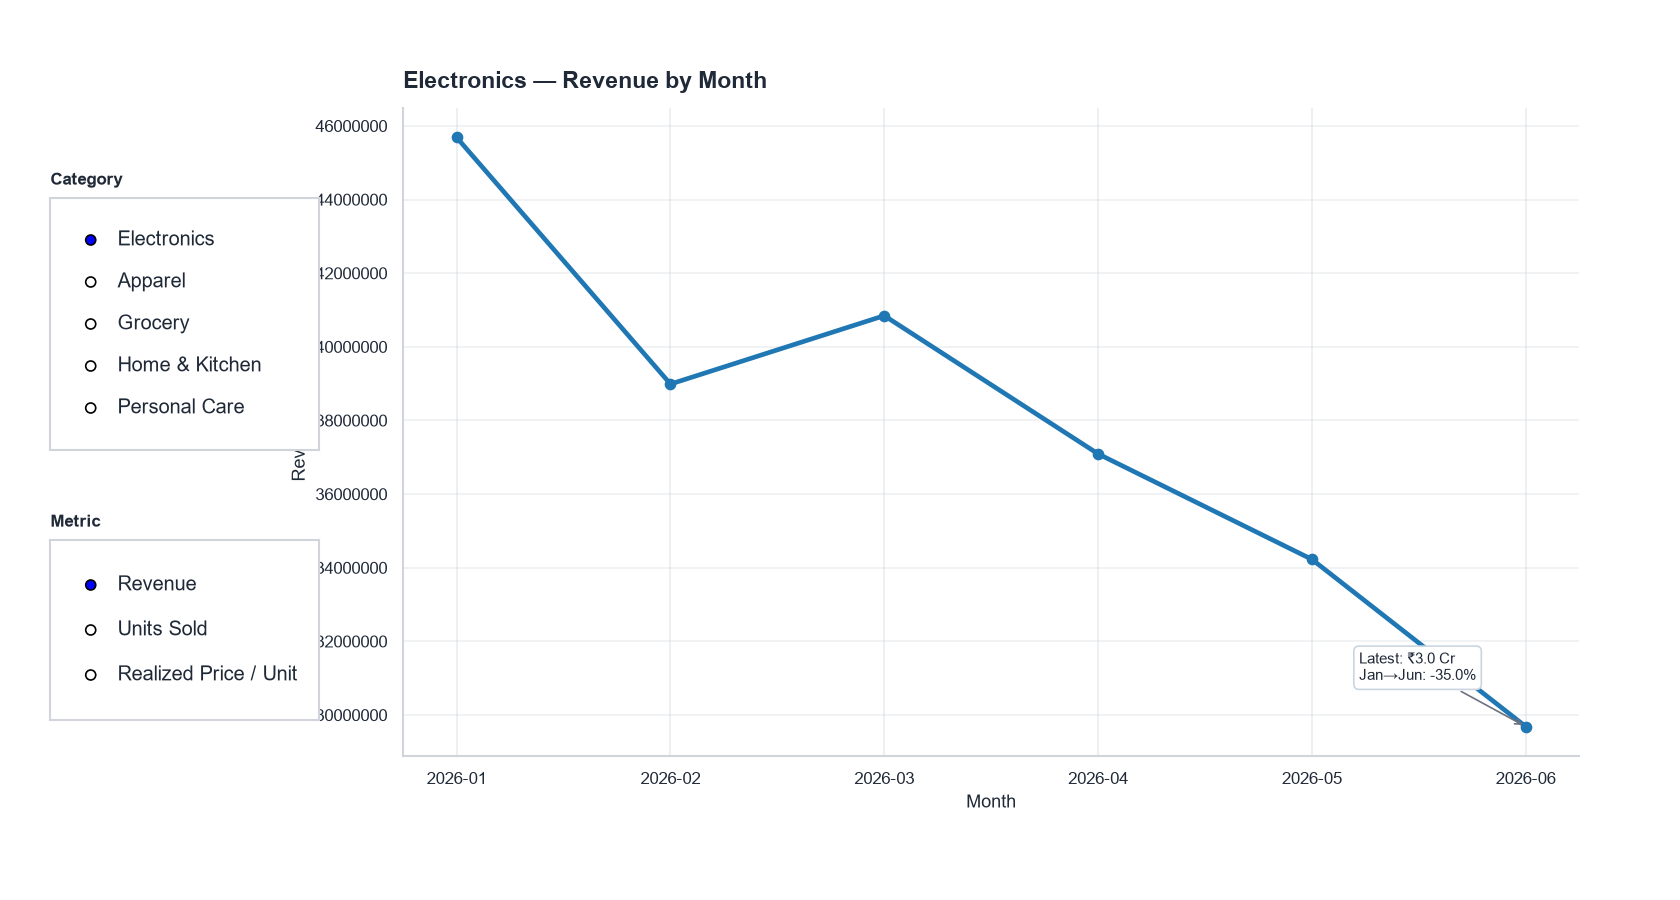

In [19]:

from matplotlib.widgets import RadioButtons


def interactive_category_panel():
    fig = plt.figure(figsize=(14, 7.5))
    ax = fig.add_axes([0.24, 0.16, 0.70, 0.72])
    cat_ax = fig.add_axes([0.03, 0.50, 0.16, 0.28])
    metric_ax = fig.add_axes([0.03, 0.20, 0.16, 0.20])

    categories = CATEGORY_ORDER
    metrics = ["Revenue", "Units Sold", "Realized Price / Unit"]

    cat_radio = RadioButtons(cat_ax, categories, active=categories.index(SELECTED_CATEGORY))
    metric_radio = RadioButtons(metric_ax, metrics, active=0)
    cat_ax.set_title("Category", fontsize=10, loc="left", pad=8)
    metric_ax.set_title("Metric", fontsize=10, loc="left", pad=8)

    def metric_series(category, metric):
        sub = df[df["category"] == category]
        if metric == "Revenue":
            s = sub.groupby("month")["revenue"].sum().reindex(MONTH_ORDER)
            ylabel = "Revenue (₹)"
        elif metric == "Units Sold":
            s = sub.groupby("month")["units_sold"].sum().reindex(MONTH_ORDER)
            ylabel = "Units Sold"
        else:
            g = sub.groupby("month").agg(Revenue=("revenue", "sum"), Units=("units_sold", "sum")).reindex(MONTH_ORDER)
            s = g["Revenue"] / g["Units"]
            ylabel = "Realized Revenue per Unit (₹)"
        return s, ylabel

    def update(_label=None):
        category = cat_radio.value_selected
        metric = metric_radio.value_selected
        series, ylabel = metric_series(category, metric)
        ax.clear()
        ax.plot(
            series.index, series.values,
            marker="o", linewidth=2.8,
            color=CATEGORY_COLORS[category]
        )
        finish_axis(ax, f"{category} — {metric} by Month", "Month", ylabel)
        if metric == "Revenue":
            ax.ticklabel_format(style="plain", axis="y")
        latest = series.iloc[-1]
        first = series.iloc[0]
        change = (latest / first - 1) * 100 if first else np.nan
        ax.annotate(
            f"Latest: {fmt_inr(latest)}\nJan→Jun: {change:+.1f}%",
            xy=(series.index[-1], latest),
            xytext=(-100, 28), textcoords="offset points",
            arrowprops=dict(arrowstyle="->", color=NEUTRAL_COLOR),
            bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="#cbd5e1"),
            fontsize=9,
        )
        fig.canvas.draw_idle()

    cat_radio.on_clicked(update)
    metric_radio.on_clicked(update)
    update()
    plt.show()

interactive_category_panel()


# 13. Analytical Limitations and Decision Boundaries

The strongest analysis is explicit about what the dataset cannot establish.

- **Profitability:** product cost and gross margin are absent, so profit impact cannot be calculated.
- **Inventory effects:** stock-on-hand and stockout data are absent, so weak sales could partly reflect availability rather than demand.
- **Promotion causality:** discount observations are not randomized experiments; the analysis shows association, not causal lift.
- **Supplier attribution:** no supplier identifier is present, so category/product evidence cannot be assigned to a named supplier.
- **Customer behavior:** there is no customer identifier or basket-level customer history, so retention, repeat purchase and customer segmentation are outside scope.

These are not reasons to discard the analysis. They define the **next data request** before a high-stakes investment decision.

# 14. Category Manager Briefing

**Apparel has the strongest growth case:** revenue increased approximately **34.1% from January to June**, supported by strong products including Saree and T-Shirt. **Electronics should be challenged in the supplier review:** its revenue declined approximately **35.0%**, and Smart TV generated **₹41.88M** over six months despite being the lowest-revenue product within Electronics. **Discounting should be scrutinised:** average revenue per transaction is about **22.5% lower at 20% discount than at 0%**, while average units sold are nearly unchanged. **Promotional timing should favour strong-demand periods such as Saturday**, while weaker periods can be used for controlled tests rather than broad discounting. Before making a final investment decision, request **product cost/gross-margin, inventory/stockout, and promotion-exposure data** so the next review can distinguish revenue performance from profitability and availability effects.

# 15. Final Submission Checklist

### Required assignment compliance
- [x] Single Jupyter `.ipynb` deliverable
- [x] CBIM Problem Canvas at the beginning
- [x] Six required analysis steps retained in sequence
- [x] Code + Markdown explanation for every required step
- [x] Business-language chart titles and axes
- [x] Top/bottom product analysis for all five categories
- [x] Discount analysis with a clear numeric position
- [x] Chain and selected-category day/month comparison
- [x] Category Manager Briefing with specific figures

### Extended distinction-oriented layer
- [x] Data-quality gate and revenue reconciliation
- [x] Category Health Scorecard
- [x] Category momentum / consistency measures
- [x] Product contribution within category
- [x] Product revenue concentration / Pareto view
- [x] Store × Category heatmap
- [x] Revenue vs Units analysis
- [x] Realized revenue per unit
- [x] Product performance map
- [x] Explicit analytical limitations
- [x] Supplier-attribution boundary

### Visualization / UI layer
- [x] Consistent category color semantics
- [x] Restrained management-style visual design
- [x] KPI cards
- [x] Direct chart annotations
- [x] Consistent formatting and whitespace
- [x] Configuration-driven category drill-down
- [x] Native Matplotlib hover helper (backend-dependent)
- [x] Native Matplotlib zoom/pan in supported interactive backends
- [x] Static fallback so the assignment does not depend on an extra dashboard framework
- [x] Extended product concentration section is self-contained (no dependency on Step 3 execution order)
- [x] Executive UI layer uses a consistent dark BI-style visual hierarchy with native Matplotlib interaction
- [x] Hover inspector exposes monthly Revenue, Units, Transactions, Realized Price/Unit and MoM change when the backend supports live events


## Sources used for the visualization design

- Matplotlib documentation on backends and Jupyter interactivity: https://matplotlib.org/stable/users/explain/figure/backends.html
- Matplotlib documentation on event-driven interaction: https://matplotlib.org/stable/users/explain/figure/interactive_guide.html

These sources were used only to verify what native Matplotlib/Jupyter interaction can support. The notebook itself remains within the assignment's required visualization stack.